In [4]:
# install.packages("tidyverse")
library(tidyverse)

# install.packages("corrplot")
library(corrplot)

### 1. Importação de Dados através de [InsideAirbnb](https://insideairbnb.com/get-the-data/) -> Tasmania

In [5]:
# ler o dataset com c("", "NA") ficar já com valores ausentes como NA
dados <- read.csv("listings.csv", stringsAsFactors = TRUE, na.strings = c("", "NA"))

dim(dados) # quantidade de linhas e colunas

[1] 6501   18

In [6]:
head(dados, 5) # primeiras 5 linhas

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
,<dbl>,<fct>,<int>,<fct>,<lgl>,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<int>,<int>,<int>,<fct>
1,35644,Central Hobart Historic Cottage,153268,Yvette,NA,Hobart,-42.87895,147.3153,Private room,NA,1,255,2020-03-08,1.64,3,0,0,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
2,88873,Terrace- 5mins to central Hobart,485048,Russell And Ingrid,NA,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,2025-09-04,3.83,1,147,50,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
3,137808,Bradman House CBD Launceston Invermay + Free WIFI,673625,Emma And Dale,NA,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2025-09-09,2.79,2,287,49,DA0518/2019
4,268482,"Anderson Suite, The Ark Stanley, Guest House",1406692,Rhonda,NA,Circular Head,-40.76490,145.2970,Private room,344,1,5,2025-01-02,0.06,7,286,1,NA
5,292399,"Rainbow Valley Retreat, Ellendale",1513972,Mandy,NA,Central Highlands,-42.62103,146.7157,Private room,120,1,248,2025-06-09,1.60,1,362,26,NA


In [7]:
str(dados) # tipos de dados

'data.frame':	6501 obs. of  18 variables:
 $ id                            : num  35644 88873 137808 268482 292399 ...
 $ name                          : Factor w/ 6447 levels "''Birch Lane''  Self- Contained B&B, Cradoc/Cygnet",..: 1303 5290 1082 453 4175 4456 1862 2729 5799 4775 ...
 $ host_id                       : int  153268 485048 673625 1406692 1513972 1514295 1670767 1777929 2404373 2417230 ...
 $ host_name                     : Factor w/ 1656 levels "Aaron","Aaron And Emma",..: 1643 1332 452 1275 988 157 732 656 1472 76 ...
 $ neighbourhood_group           : logi  NA NA NA NA NA NA ...
 $ neighbourhood                 : Factor w/ 29 levels "Break O'Day",..: 15 15 21 6 5 15 14 19 21 27 ...
 $ latitude                      : num  -42.9 -42.9 -41.4 -40.8 -42.6 ...
 $ longitude                     : num  147 147 147 145 147 ...
 $ room_type                     : Factor w/ 4 levels "Entire home/apt",..: 3 1 1 3 3 3 1 3 1 1 ...
 $ price                         : int  NA 113 245 344

In [8]:
summary(dados) # estatísticas básicas

       id                                                            name     
 Min.   :3.564e+04   Ben Lomond Creek Cabins                           :   4  
 1st Qu.:2.812e+07   $0 No cleaning fee                                :   3  
 Median :5.400e+07   Anabel's Queen Room with Garden View              :   3  
 Mean   :5.239e+17   Aquila Eco Retreat - the ultimate romantic getaway:   3  
 3rd Qu.:1.060e+18   Bfst inc | Historic Glencoe Farmhouse Ensuite Room:   3  
 Max.   :1.507e+18   Leolanda's Airbnb! Private room in sunlit house   :   3  
                     (Other)                                           :6482  
    host_id                             host_name    neighbourhood_group
 Min.   :    22961   Moxxi                   : 142   Mode:logical       
 1st Qu.: 27146791   Emily                   : 129   NA's:6501          
 Median :100747967   Freycinet Holiday Houses: 103                      
 Mean   :175240250   Donna                   :  79                      
 3r

### 2. Limpeza de Dados

O que podemos observar de imediato com os outputs observados acima: 

- **price** tem **835 NAs** e sendo a variável alvo, estas linhas têm de ser removidas
- **price** tem um valor máximo de **15.108** com uma mediana de 198. O **outlier** tem de ser removido.
- **neighbourhood_group** tem tudo NA, logo é uma coluna facilmente descartável.
- **id, host_id, name, host_name** são colunas identificadoras, não têm valor preditivo nenhum. 
- **reviews_per_month** tem 369 NAs, logo são listings sem reviews, podemos imputar 0
- **minimum_nights** tem um max de 730, outlier

In [9]:
# Cópia de dados para limpeza
df <- dados

# Contar quantos valores ausentes existem em cada coluna
sapply(df, function(x) sum(is.na(x)))

id                           name 
                             0                              0 
                       host_id                      host_name 
                             0                              0 
           neighbourhood_group                  neighbourhood 
                          6501                              0 
                      latitude                      longitude 
                             0                              0 
                     room_type                          price 
                             0                            835 
                minimum_nights              number_of_reviews 
                             0                              0 
                   last_review              reviews_per_month 
                           369                            369 
calculated_host_listings_count               availability_365 
                             0                              0 
         number_of_reviews_ltm                        license 
                             0                            260

### Justificação das variáveis removidas

As seguintes colunas foram excluídas do modelo por razões específicas: 

* **neighbourhood_group**: completamente vazia (6501 NAs)

* **id** e **host_id**: identificadores únicos, não descrevem características do alojamento

* **name** e **host_name**: texto livre e demasiado específico; não generalizável num modelo de regressão

* **license**: 2480 níveis distintos, maioritariamente texto livre

* **last_review**: data em formato texto; a conversão para "dias desde última review" foi considerada mas 'reviews_per_month' e 'number_of_reviews_ltm' já capturam a atividade recente do alojamento de forma mais direta

* **calculated_host_listings_count**: fortemente assimétrica (max=142) e com correlação elevada com outras variáveis de review; removida para evitar multicolinearidade

In [10]:
# Remocao de colunas
df <- dplyr::select(df, -id, -name, -host_id, -host_name,
                    -neighbourhood_group, -license, -last_review,
                    -calculated_host_listings_count)

# Remocao de linhas com NA na variavel alvo (price)
df <- df %>% drop_na(price)

# Alojamentos sem avaliacoes ainda nao tem reviews, substituir NA por 0
df$reviews_per_month[is.na(df$reviews_per_month)] <- 0

# Remocao de alojamentos com minimo de noites superior a 30
# Acima deste valor, os alojamentos enquadram-se em arrendamentos de longa duracao
# e tem um comportamento de precos distinto dos alojamentos de curta estadia
df <- df %>% filter(minimum_nights <= 30)

# Remocao de outliers de preco acima do percentil 99
limite_superior <- quantile(df$price, 0.99)
df <- df[df$price <= limite_superior, ]

In [11]:
# Verificação: confirmar que não restam NAs no dataset
is.na(df) %>% sum()

[1] 0

In [12]:
# Certificação que nenhuma variável tem desvio padrão = 0
sd_values <- df %>%
  summarise(across(where(is.numeric), sd))
sd_values


latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.827514,0.7554613,123.7131,1.646114,140.0409,1.886356,101.1752,22.90984


In [13]:
str(df)
summary(df)

'data.frame':	5602 obs. of  10 variables:
 $ neighbourhood        : Factor w/ 29 levels "Break O'Day",..: 15 21 6 5 15 14 21 27 1 15 ...
 $ latitude             : num  -42.9 -41.4 -40.8 -42.6 -42.9 ...
 $ longitude            : num  147 147 145 147 147 ...
 $ room_type            : Factor w/ 4 levels "Entire home/apt",..: 1 1 3 3 3 1 1 1 1 1 ...
 $ price                : int  113 245 344 120 48 223 311 390 315 210 ...
 $ minimum_nights       : int  2 1 1 1 2 2 2 2 2 1 ...
 $ number_of_reviews    : int  668 461 5 248 160 59 481 80 96 23 ...
 $ reviews_per_month    : num  3.83 2.79 0.06 1.6 1.03 0.5 3.12 0.55 0.66 0.45 ...
 $ availability_365     : int  147 287 286 362 348 244 335 299 315 326 ...
 $ number_of_reviews_ltm: int  50 49 1 26 14 5 52 2 6 9 ...


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
 Shared room    :   0   Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [14]:
unique(df$room_type)
print("Contagem de cada tipo de quarto no df pré limpeza de NA's:")
table(dados$room_type)

# 'room_type' tem 4 níveis, mas só 3 são relevantes para o nosso modelo (então vamos eliminar o Shared Room, que ficou com 0 valores)
df$room_type <- droplevels(df$room_type)

print("Contagem de cada tipo de quarto no df pós limpeza de NA's:")
table(df$room_type)

[1] Entire home/apt Private room    Hotel room     
Levels: Entire home/apt Hotel room Private room Shared room

[1] "Contagem de cada tipo de quarto no df pré limpeza de NA's:"



Entire home/apt      Hotel room    Private room     Shared room 
           5721              81             698               1 

[1] "Contagem de cada tipo de quarto no df pós limpeza de NA's:"



Entire home/apt      Hotel room    Private room 
           5019              59             524 

In [15]:
# Vamos verificar se o mesmo aconteceu em neighbourhood
table(df$neighbourhood)


         Break O'Day             Brighton               Burnie 
                 335                   10                   53 
       Central Coast    Central Highlands        Circular Head 
                 141                   65                  131 
            Clarence       Derwent Valley            Devonport 
                 377                   73                  103 
              Dorset             Flinders          George Town 
                 180                   28                   61 
Glamorgan/Spring Bay            Glenorchy               Hobart 
                 515                  117                 1067 
         Huon Valley              Kentish          King Island 
                 216                  106                   37 
         Kingborough              Latrobe           Launceston 
                 409                   72                  587 
      Meander Valley    Northern Midlands               Sorell 
                 110                   

In [16]:
# Verificação final dos dados para ver se está tudo OK
head(df)
summary(df)

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,3.83,147,50
2,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2.79,287,49
3,Circular Head,-40.76490,145.2970,Private room,344,1,5,0.06,286,1
4,Central Highlands,-42.62103,146.7157,Private room,120,1,248,1.60,362,26
5,Hobart,-42.86919,147.3000,Private room,48,2,160,1.03,348,14
6,Glenorchy,-42.77935,147.2560,Entire home/apt,223,2,59,0.50,244,5


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
                        Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [17]:
# Criação da variável log_price 
df$log_price <- log(df$price)

### 3. Exploração dos Dados

In [18]:
# Criar subconjunto apenas com variaveis numericas para analise
# Excluir latitude e longitude pois serao usadas apenas no mapa
df_numeric <- df %>%
  dplyr::select(price, minimum_nights, number_of_reviews,
                reviews_per_month, availability_365, number_of_reviews_ltm) 

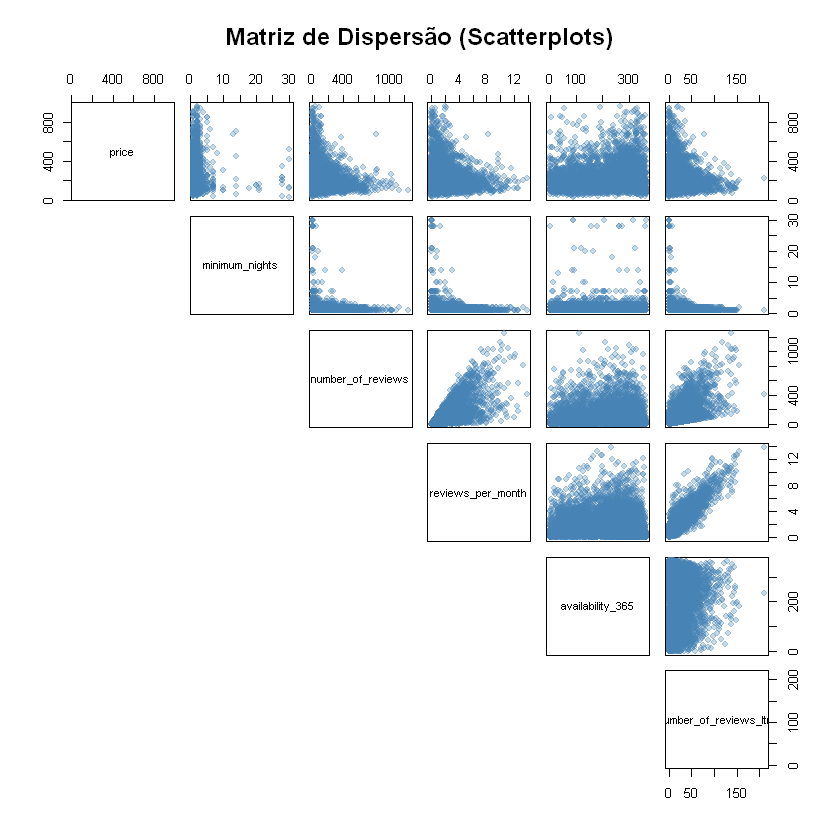

In [19]:
# Matriz de Dispersão
df_numeric %>%
pairs(main = "Matriz de Dispersão (Scatterplots)", 
      pch = 19,               
      col = alpha("steelblue", 0.3), 
      lower.panel = NULL)

#### Distribuição de Preço (Price)

O histograma é _right-skewed_, dado que existem propriedades de luxo - _outliers_ - com preços por noite bastante acima da média 

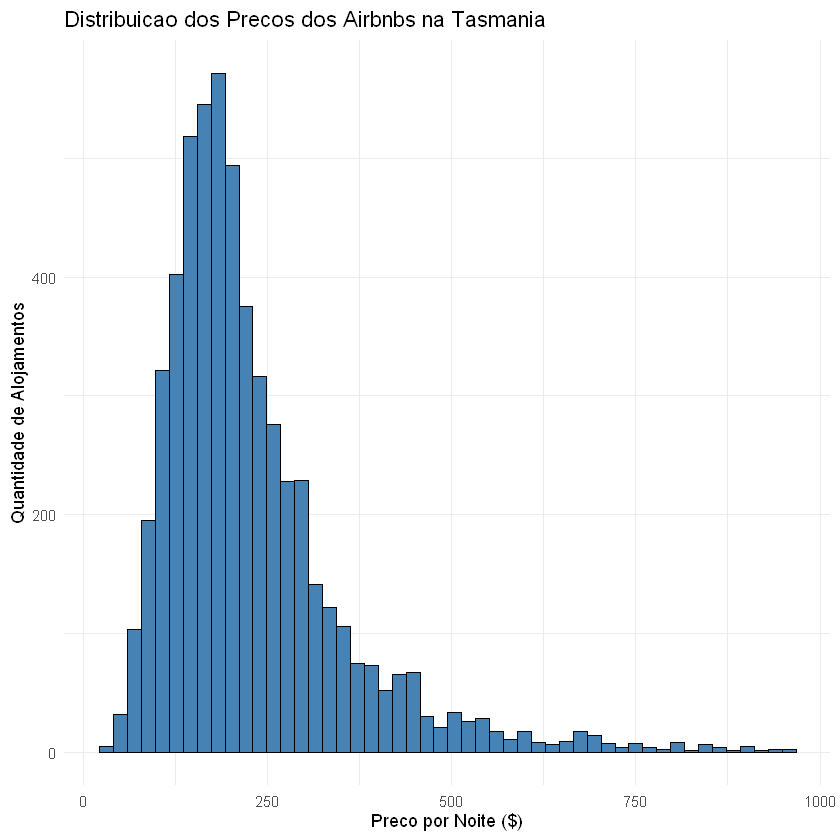

In [20]:
# Distribuicao do preco (variavel alvo)
ggplot(df, aes(x = price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao dos Precos dos Airbnbs na Tasmania",
       x = "Preco por Noite ($)",
       y = "Quantidade de Alojamentos")

### Preço vs Tipo de Quarto

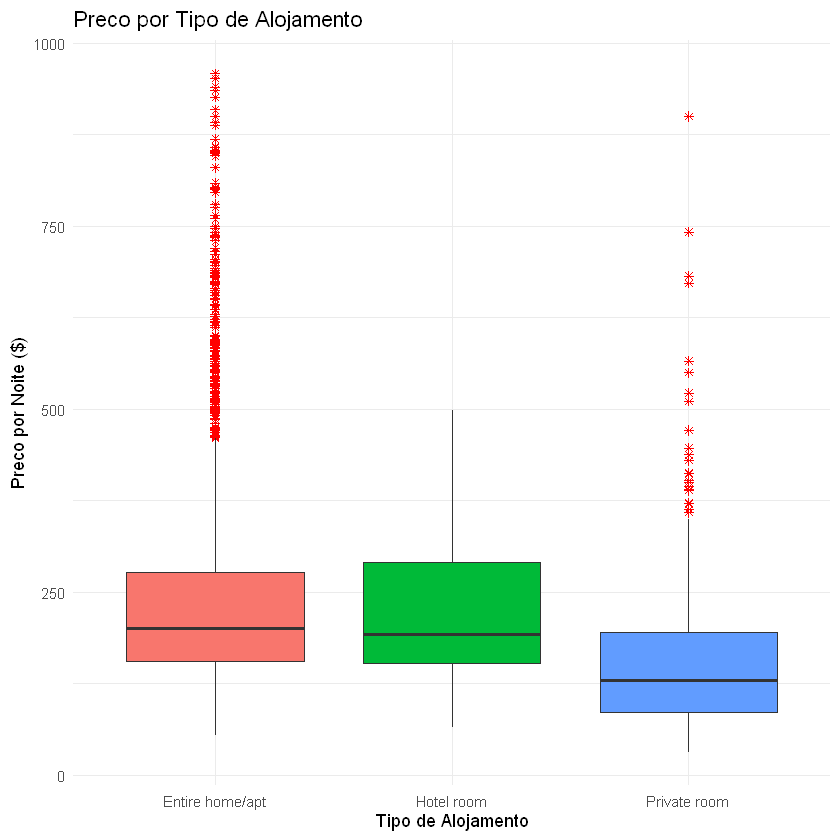

In [21]:
# Distribuicao do preco por tipo de alojamento
ggplot(df, aes(x = room_type, y = price, fill = room_type)) +
  geom_boxplot(outlier.color = "red", outlier.shape = 8) +
  theme_minimal() +
  labs(title = "Preco por Tipo de Alojamento",
       x = "Tipo de Alojamento",
       y = "Preco por Noite ($)") +
  theme(legend.position = "none")

### Visuaização das propriedades em coordenadas

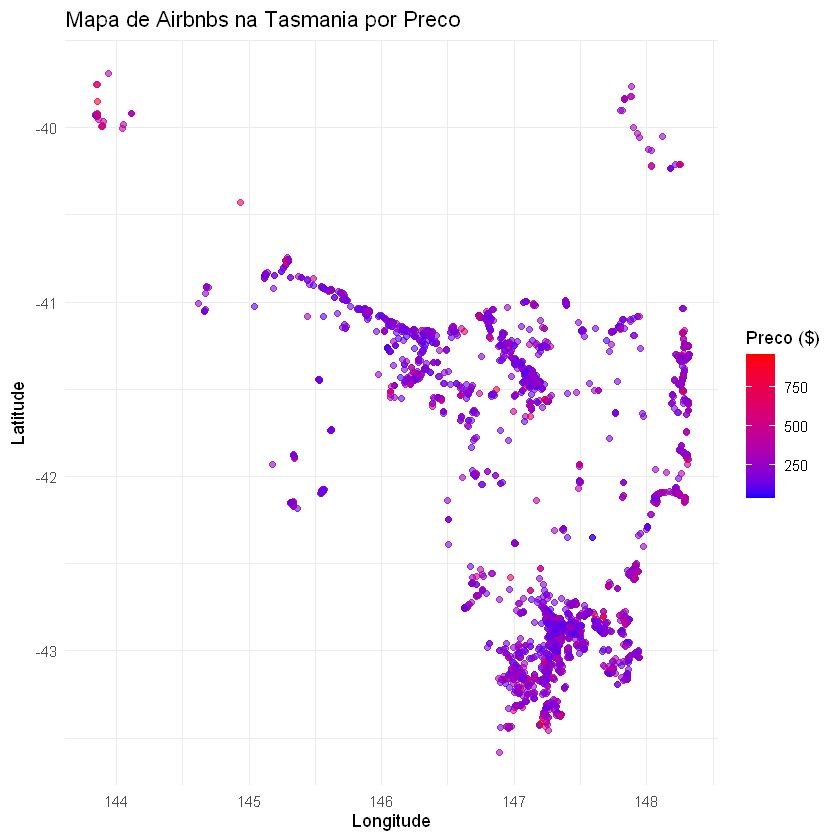

In [22]:
# Mapa de localizacao dos alojamentos colorido pelo preco
ggplot(df, aes(x = longitude, y = latitude, color = price)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_gradient(low = "blue", high = "red") +
  theme_minimal() +
  labs(title = "Mapa de Airbnbs na Tasmania por Preco",
       x = "Longitude",
       y = "Latitude",
       color = "Preco ($)")

### Disponibilidade 365 dias vs Preço

`geom_smooth()` using formula = 'y ~ x'


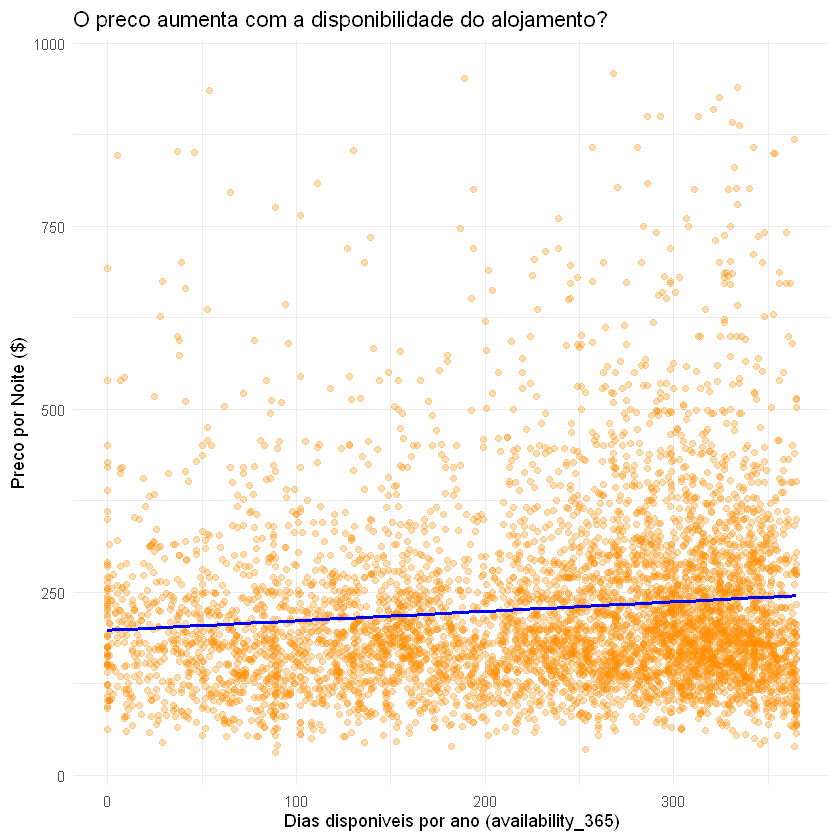

In [23]:
# Relacao entre disponibilidade anual e preco
ggplot(df, aes(x = availability_365, y = price)) +
  geom_point(alpha = 0.3, color = "darkorange") +
  geom_smooth(method = "lm", color = "blue", se = FALSE) +
  theme_minimal() +
  labs(title = "O preco aumenta com a disponibilidade do alojamento?",
       x = "Dias disponiveis por ano (availability_365)",
       y = "Preco por Noite ($)")

### Top 10 Bairros com mais Airbnbs

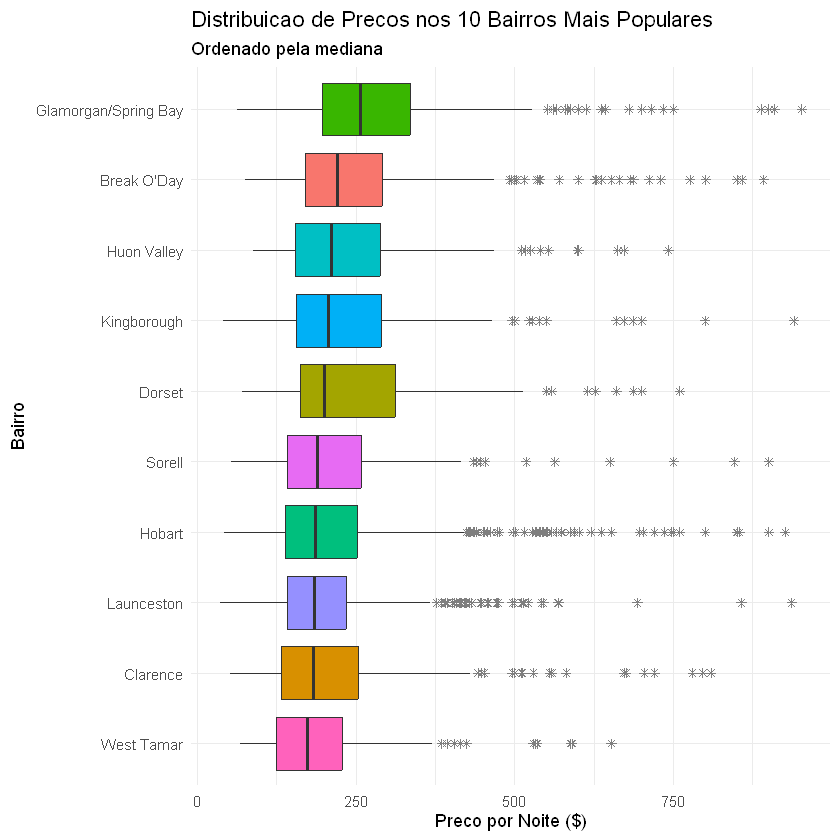

In [24]:
# Distribuicao de precos nos 10 bairros com mais alojamentos
top_10_bairros <- df %>%
  as_tibble() %>%
  dplyr::count(neighbourhood, sort = TRUE) %>%
  head(10) %>%
  dplyr::pull(neighbourhood)

df %>%
  dplyr::filter(neighbourhood %in% top_10_bairros) %>%
  ggplot(aes(x = reorder(neighbourhood, price, FUN = median),
             y = price,
             fill = neighbourhood)) +
  geom_boxplot(outlier.color = "gray50", outlier.shape = 8) +
  coord_flip() +
  theme_minimal() +
  labs(title = "Distribuicao de Precos nos 10 Bairros Mais Populares",
       subtitle = "Ordenado pela mediana",
       x = "Bairro",
       y = "Preco por Noite ($)") +
  theme(legend.position = "none")

### Distribuição do número mínimo de noites

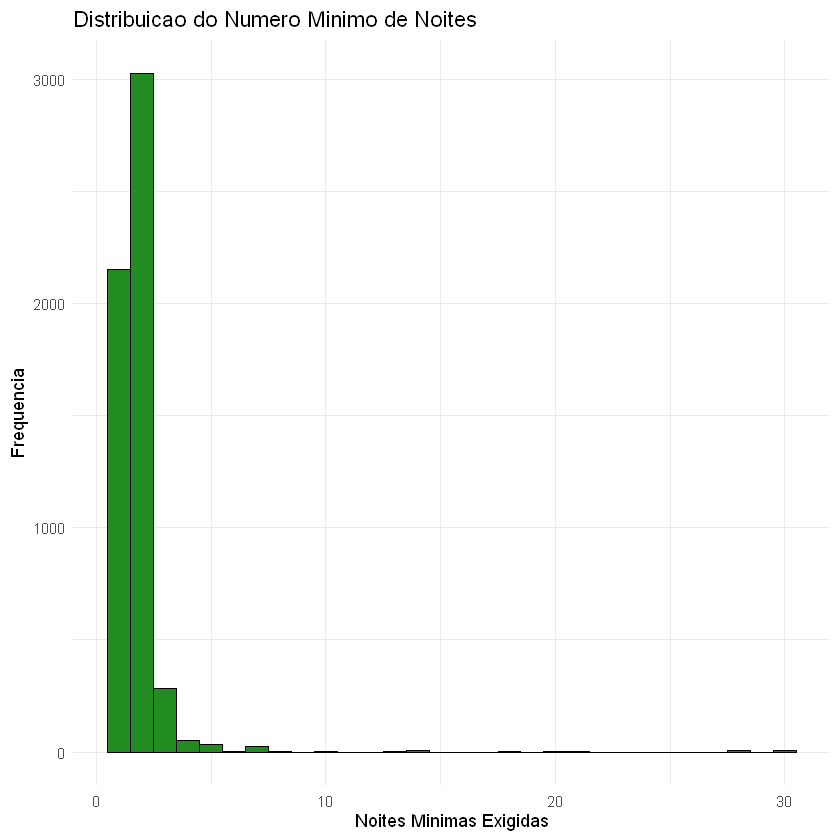

In [25]:
# Distribuicao do numero minimo de noites exigido
ggplot(df, aes(x = minimum_nights)) +
  geom_histogram(fill = "forestgreen", color = "black", bins = 30) +
  theme_minimal() +
  labs(title = "Distribuicao do Numero Minimo de Noites",
       x = "Noites Minimas Exigidas",
       y = "Frequencia")

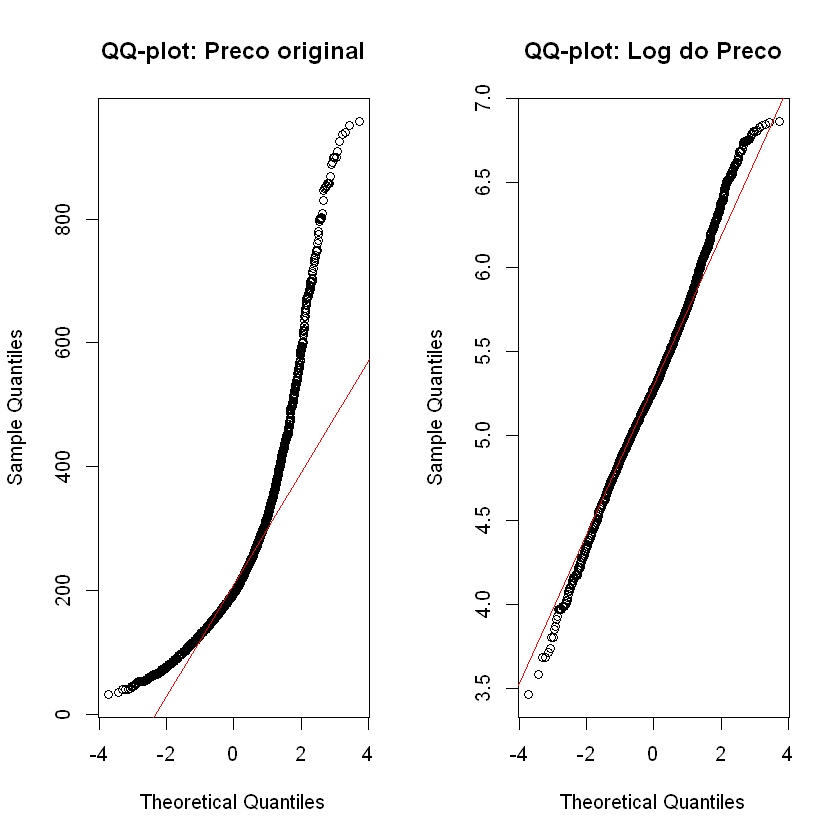

In [26]:
par(mfrow = c(1, 2))
qqnorm(df$price, main = "QQ-plot: Preco original")
qqline(df$price, col = "red")

qqnorm(df$log_price, main = "QQ-plot: Log do Preco")
qqline(df$log_price, col = "red")
par(mfrow = c(1, 1))

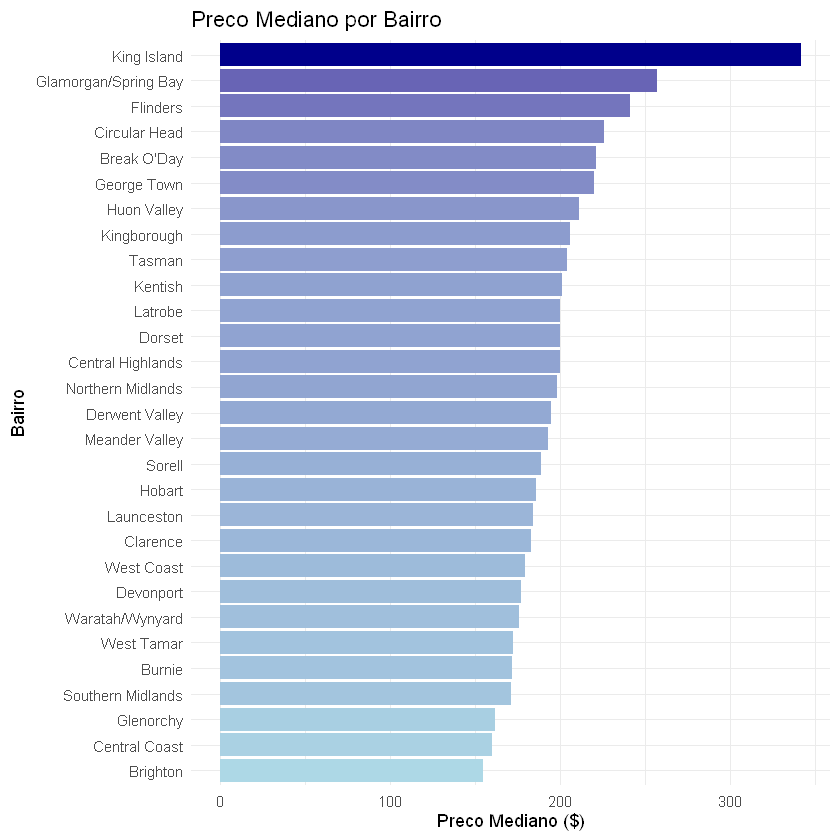

In [27]:
df %>%
  group_by(neighbourhood) %>%
  summarise(preco_mediano = median(price)) %>%
  ggplot(aes(x = reorder(neighbourhood, preco_mediano), y = preco_mediano, fill = preco_mediano)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  theme_minimal() +
  labs(title = "Preco Mediano por Bairro",
       x = "Bairro",
       y = "Preco Mediano ($)") +
  theme(legend.position = "none")

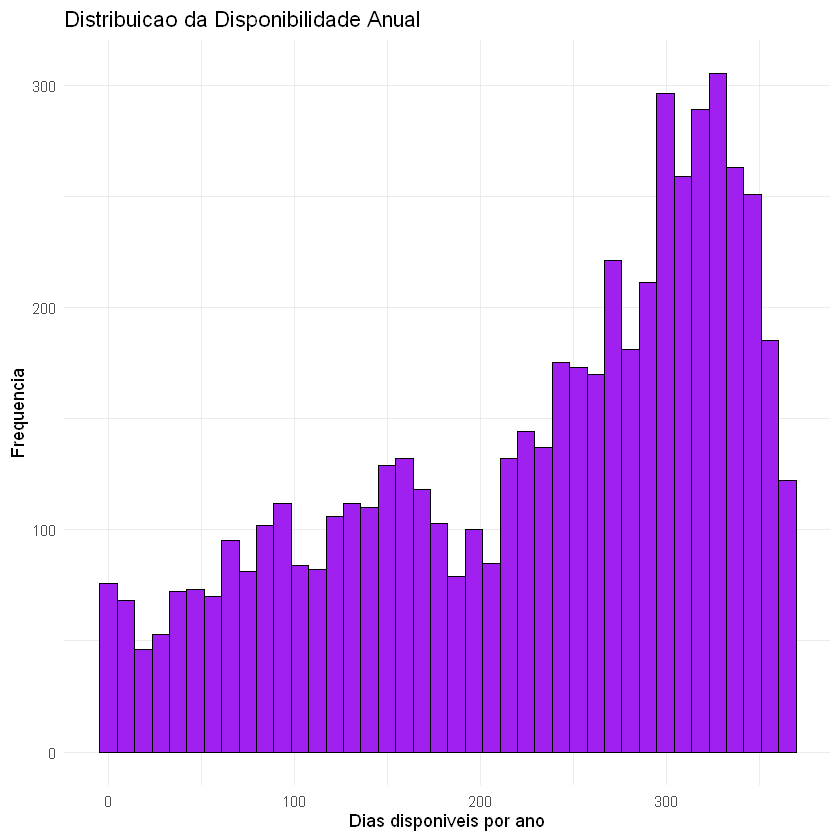

In [28]:
ggplot(df, aes(x = availability_365)) +
  geom_histogram(fill = "purple", color = "black", bins = 40) +
  theme_minimal() +
  labs(title = "Distribuicao da Disponibilidade Anual",
       x = "Dias disponiveis por ano",
       y = "Frequencia")

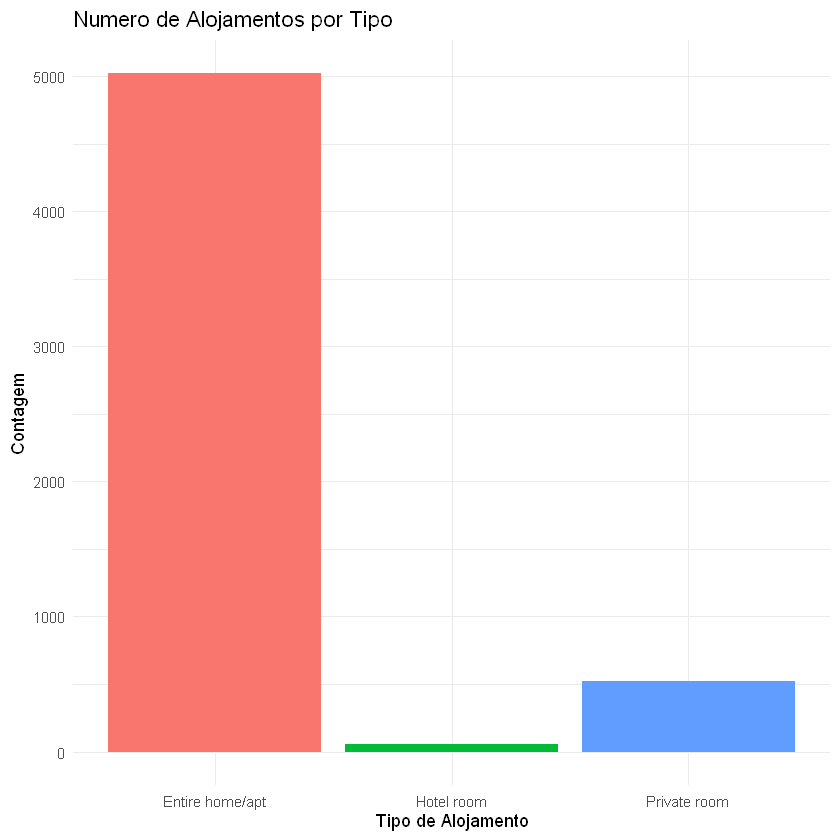

In [29]:
ggplot(df, aes(x = room_type, fill = room_type)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Numero de Alojamentos por Tipo",
       x = "Tipo de Alojamento",
       y = "Contagem") +
  theme(legend.position = "none")

### 4. Correlação de Variáveis

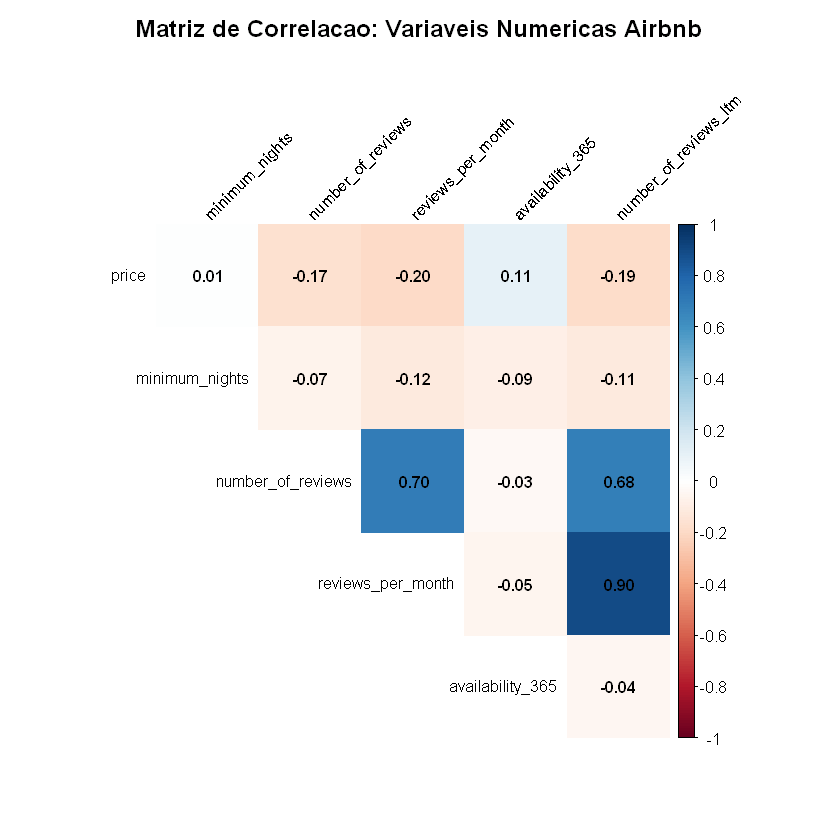

In [30]:
# Matriz de correlacao entre variaveis numericas
# Usamos df_numeric que ja exclui latitude, longitude e calculated_host_listings_count
matriz_cor <- cor(df_numeric, use = "complete.obs")

par(mar = c(1, 1, 3, 1))

corrplot(matriz_cor,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         number.cex = 0.8,
         tl.col = "black",
         tl.srt = 45,
         tl.cex = 0.8,
         diag = FALSE)

title("Matriz de Correlacao: Variaveis Numericas Airbnb", line = 1.5, cex.main = 1.2)

# As tres variaveis de reviews (number_of_reviews, reviews_per_month e
# number_of_reviews_ltm) estao altamente correlacionadas entre si (r > 0.8)

# Manter apenas number_of_reviews_ltm pois representa a atividade recente
# do alojamento, sendo mais relevante para o preco atual do que o historico total

**Multicolinearidade** — number_of_reviews e number_of_reviews_ltm têm correlação de 0.90. 
São praticamente a mesma informação (reviews totais vs reviews no último ano). Usar as duas no mesmo modelo é problemático. reviews_per_month também está correlacionada com ambas (0.70 e 0.68). Isto justifica escolher apenas uma destas variáveis e number_of_reviews_ltm é a melhor escolha porque captura atividade recente, que é mais relevante para o preço atual.

O **preço tem correlações fracas com tudo**: o valor mais alto é -0.20 com reviews_per_month. Isto implica uma necessidade de variáveis categóricas como room_type e neighbourhood para explicar o preço.

### 5. Feature Engineering

In [31]:
# Remover latitude e longitude - ja nao sao necessarias apos o mapa
# Remover tambem as duas variaveis de reviews redundantes identificadas na correlacao
df <- df %>%
  dplyr::select(-latitude, -longitude, -number_of_reviews, -reviews_per_month)

names(df)

[1] "neighbourhood"         "room_type"             "price"                
[4] "minimum_nights"        "availability_365"      "number_of_reviews_ltm"
[7] "log_price"

In [32]:
# Transformacao logaritmica do preco para corrigir a assimetria da distribuicao
df <- df %>%
  mutate(log_price = log(price))

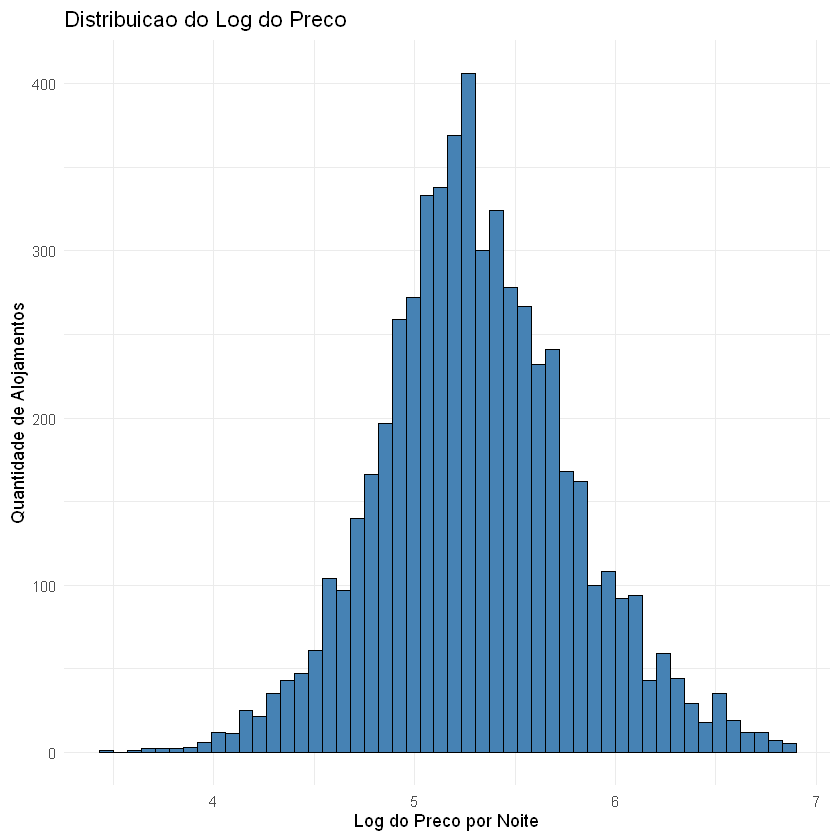

In [33]:
# Confirmacao visual da distribuicao apos transformacao logaritmica
# Deve aproximar-se de uma distribuicao normal
ggplot(df, aes(x = log_price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao do Log do Preco",
       x = "Log do Preco por Noite",
       y = "Quantidade de Alojamentos")

In [34]:
# Verificar a distribuicao de alojamentos por bairro
tabela_bairros <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros) <- c("neighbourhood", "n")
tabela_bairros$percentagem <- round(prop.table(tabela_bairros$n) * 100, 2)
tabela_bairros

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28
Dorset,180,3.21


In [35]:
# Bairros com menos de 2% dos alojamentos sao agrupados em "Outro"
# Reduz o numero de categorias e evita niveis com muito poucas observacoes
# que podem causar instabilidade nos modelos
df <- df %>%
  mutate(neighbourhood = fct_lump_prop(neighbourhood,
                                       prop = 0.02,
                                       other_level = "Outro"))

# Confirmar resultado do agrupamento
tabela_bairros_final <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros_final) <- c("neighbourhood", "n")
tabela_bairros_final$percentagem <- round(prop.table(tabela_bairros_final$n) * 100, 2)
tabela_bairros_final

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Outro,935,16.69
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28


### Divisão em treino e teste

In [36]:
# Divisao estratificada do dataset em treino (80%) e teste (20%)
# A estratificacao por room_type garante que a proporcao de cada tipo de quarto
# e mantida em ambos os conjuntos, importante dado o desequilibrio existente
set.seed(131651)
indices_treino <- sample(1:nrow(df), size = 0.80 * nrow(df))

df_train <- df[indices_treino, ]
df_test  <- df[-indices_treino, ]

cat("Numero de observacoes no Treino:", nrow(df_train), "\n")
cat("Numero de observacoes no Teste:", nrow(df_test), "\n")

# Confirmar que as proporcoes foram mantidas
cat("\nDistribuicao no Treino:\n")
print(round(prop.table(table(df_train$room_type)) * 100, 1))

cat("\nDistribuicao no Teste:\n")
print(round(prop.table(table(df_test$room_type)) * 100, 1))

Numero de observacoes no Treino: 4481 
Numero de observacoes no Teste: 1121 

Distribuicao no Treino:

Entire home/apt      Hotel room    Private room 
           89.6             1.0             9.4 

Distribuicao no Teste:

Entire home/apt      Hotel room    Private room 
           89.7             1.1             9.3 


### 6. Usar algoritmos de aprendizagem supervisionada (regressão linear, regressão polinomial, interação de variáveis, regressão não-linear) sobre o seu conjunto de dados

##### 6.1.1 Modelo de Regressão Linear Simples

In [37]:
# Modelo 1: Regressao Linear Simples
# Usado como baseline - apenas uma variavel preditora
# Esperamos um R² baixo, o objetivo e ter um ponto de comparacao
modelo1_simples <- lm(log_price ~ number_of_reviews_ltm, data = df_train)
summary(modelo1_simples)


Call:
lm(formula = log_price ~ number_of_reviews_ltm, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.92120 -0.30599 -0.01403  0.29119  1.56209 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            5.3911441  0.0095680  563.46   <2e-16 ***
number_of_reviews_ltm -0.0042089  0.0003091  -13.62   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4769 on 4479 degrees of freedom
Multiple R-squared:  0.03974,	Adjusted R-squared:  0.03953 
F-statistic: 185.4 on 1 and 4479 DF,  p-value: < 2.2e-16


##### 6.1.2 Modelo de Regressão Linear Múltipla

In [38]:
# Modelo 2: Regressao Linear Multipla
# Inclui todas as variaveis relevantes apos feature engineering
modelo2_multipla <- lm(log_price ~ neighbourhood + room_type +
                                   minimum_nights + number_of_reviews_ltm +
                                   availability_365,
                       data = df_train)
summary(modelo2_multipla)


Call:
lm(formula = log_price ~ neighbourhood + room_type + minimum_nights + 
    number_of_reviews_ltm + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.46256 -0.29988 -0.02758  0.25076  1.90372 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.502e+00  3.312e-02 166.119  < 2e-16 ***
neighbourhoodCentral Coast        -2.295e-01  4.923e-02  -4.662 3.23e-06 ***
neighbourhoodCircular Head         4.854e-02  5.055e-02   0.960 0.336908    
neighbourhoodClarence             -1.740e-01  3.657e-02  -4.758 2.02e-06 ***
neighbourhoodDorset               -1.041e-01  4.583e-02  -2.272 0.023151 *  
neighbourhoodGlamorgan/Spring Bay  9.362e-02  3.437e-02   2.724 0.006478 ** 
neighbourhoodGlenorchy            -3.208e-01  5.391e-02  -5.950 2.89e-09 ***
neighbourhoodHobart               -1.547e-01  3.074e-02  -5.032 5.04e-07 ***
neighbourhoodHuon Valley          -6.543e-02  4

##### 6.2 Modelo de Regressão Polinomial

In [39]:
# Modelo 3: Regressao Polinomial
# Igual ao Modelo 2 mas com termo quadratico em number_of_reviews_ltm
# Testa se a relacao entre reviews e preco e nao-linear
modelo3_poli <- lm(log_price ~ neighbourhood + room_type +
                               poly(number_of_reviews_ltm, 2) +
                               minimum_nights + availability_365,
                   data = df_train)
summary(modelo3_poli)


Call:
lm(formula = log_price ~ neighbourhood + room_type + poly(number_of_reviews_ltm, 
    2) + minimum_nights + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.49713 -0.29740 -0.02826  0.25688  1.88245 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.401e+00  3.206e-02 168.441  < 2e-16 ***
neighbourhoodCentral Coast        -2.313e-01  4.898e-02  -4.722 2.41e-06 ***
neighbourhoodCircular Head         4.910e-02  5.029e-02   0.976 0.328896    
neighbourhoodClarence             -1.693e-01  3.639e-02  -4.653 3.37e-06 ***
neighbourhoodDorset               -1.033e-01  4.560e-02  -2.266 0.023498 *  
neighbourhoodGlamorgan/Spring Bay  8.820e-02  3.421e-02   2.579 0.009955 ** 
neighbourhoodGlenorchy            -3.166e-01  5.364e-02  -5.903 3.83e-09 ***
neighbourhoodHobart               -1.471e-01  3.061e-02  -4.805 1.60e-06 ***
neighbourhoodHuon Valley          -6.4

##### 6.3 Modelo de Regressão Não Linear

In [40]:
# Modelo 4: Regressao com Interacao
# Regressão não-linear: transformação log no preditor
# log(x) -> relação não-linear entre x e y no espaço original
modelo_naolinear <- lm(log_price ~ neighbourhood + room_type +
                                   log(minimum_nights + 1) +
                                   log(number_of_reviews_ltm + 1) +
                                   availability_365,
                       data = df_train)
summary(modelo_naolinear)


Call:
lm(formula = log_price ~ neighbourhood + room_type + log(minimum_nights + 
    1) + log(number_of_reviews_ltm + 1) + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.54860 -0.29362 -0.02518  0.25208  1.84361 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.736e+00  4.373e-02 131.168  < 2e-16 ***
neighbourhoodCentral Coast        -2.484e-01  4.871e-02  -5.100 3.54e-07 ***
neighbourhoodCircular Head         2.579e-02  5.008e-02   0.515 0.606592    
neighbourhoodClarence             -1.805e-01  3.617e-02  -4.990 6.26e-07 ***
neighbourhoodDorset               -1.089e-01  4.534e-02  -2.401 0.016370 *  
neighbourhoodGlamorgan/Spring Bay  7.442e-02  3.402e-02   2.187 0.028775 *  
neighbourhoodGlenorchy            -3.311e-01  5.333e-02  -6.209 5.82e-10 ***
neighbourhoodHobart               -1.546e-01  3.044e-02  -5.079 3.95e-07 ***
neighbourhoodHuon Valley     

##### 6.4 Regressão Linear com Interação

In [41]:
# (neighbourhood * room_type cria a interação entre o bairro e o tipo de quarto)
modelo_interacao <- lm(log_price ~ neighbourhood * room_type + minimum_nights + number_of_reviews_ltm, 
                       data = df_train)

summary(modelo_interacao)


Call:
lm(formula = log_price ~ neighbourhood * room_type + minimum_nights + 
    number_of_reviews_ltm, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.50745 -0.29435 -0.02705  0.24903  1.90162 

Coefficients: (7 not defined because of singularities)
                                                          Estimate Std. Error
(Intercept)                                              5.6090708  0.0297884
neighbourhoodCentral Coast                              -0.2461430  0.0555314
neighbourhoodCircular Head                              -0.0354118  0.0568481
neighbourhoodClarence                                   -0.1398304  0.0385492
neighbourhoodDorset                                     -0.0925774  0.0476054
neighbourhoodGlamorgan/Spring Bay                        0.1005338  0.0354880
neighbourhoodGlenorchy                                  -0.2914195  0.0568406
neighbourhoodHobart                                     -0.1561810  0.0321651
neighbourhoodHuo